# Bilbiotecas

In [70]:
import pandas               as pd
import numpy                as np
import matplotlib.pyplot    as plt
import seaborn              as sns
import statsmodels.api      as sm
import math
import joblib
import json

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import RobustScaler
from sklearn.linear_model       import LogisticRegression
from sklearn.metrics            import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay
    )

# Dataset

In [71]:
dataset = pd.read_csv('dados_brutos\\tarefas_clientes_logistic_regression.csv', sep=';')
# Convertendo colunas object com vírgula para float numérico
colunas_para_ajustar = ['perc_prioridade_maxima'] + \
    list(dataset.filter(regex='^media_').columns) + \
    list(dataset.filter(regex='valor_').columns)

for col in colunas_para_ajustar:
    dataset[col] = dataset[col].astype(str).str.replace(',', '.').astype(float)

dataset.head()

,cod_cliente,primeira_assinatura,valor_ativo_total,valor_cancelado_total,qtd_contratos_ativos,qtd_contratos_cancelados,flg_ja_sofreu_downgrade,tarefas_90d,qtd_tarefas_total,media_dias_exec,...,qtd_categorias_distintas,qtd_subcategorias_distintas,qtd_grupos_envolvidos,qtd_prioridade_normal,qtd_prioridade_parcial,qtd_prioridade_urgente,qtd_prioridade_maxima,qtd_prioridade_reforco,perc_prioridade_maxima,churn
0,10,2013-05-04,0.00,248.45,0,1,0,0,4,64.5000,...,3,2,4,4,0,0,0,0,0.00,1
1,20,2001-03-20,3369.25,0.00,1,0,0,14,710,21.7357,...,39,88,23,686,4,13,7,0,0.99,0
2,22,2011-03-21,0.00,545.60,0,2,0,0,77,12.2727,...,16,27,13,75,0,0,2,0,2.60,1
3,29,2020-10-30,1287.06,0.00,1,0,0,0,19,22.6316,...,9,11,7,17,1,0,1,0,5.26,0
4,32,2012-02-13,0.00,8153.38,0,1,0,0,157,48.8854,...,21,29,16,155,1,1,0,0,0.00,1


In [72]:
dataset.isnull().sum().sum()

0

In [73]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4669 entries, 0 to 4668
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cod_cliente                  4669 non-null   int64  
 1   primeira_assinatura          4669 non-null   object 
 2   valor_ativo_total            4669 non-null   float64
 3   valor_cancelado_total        4669 non-null   float64
 4   qtd_contratos_ativos         4669 non-null   int64  
 5   qtd_contratos_cancelados     4669 non-null   int64  
 6   flg_ja_sofreu_downgrade      4669 non-null   int64  
 7   tarefas_90d                  4669 non-null   int64  
 8   qtd_tarefas_total            4669 non-null   int64  
 9   media_dias_exec              4669 non-null   float64
 10  qt_tarefas_sd                4669 non-null   int64  
 11  media_dias_exec_tarefa_sd    4669 non-null   float64
 12  qt_tarefas_hd                4669 non-null   int64  
 13  media_dias_exec_ta

In [74]:
media_dias_ano_bissexto = 30.44

# Por que não usar apenas 30?
# Se você dividir o total de dias por 30 em uma base histórica longa
# (como um cliente que está com você desde 2011, igual ao exemplo do cliente 17029),
# o modelo vai acumular um erro de quase 5 dias por ano. No longo prazo, isso faria o
# cálculo do Tenure (tempo de casa) parecer maior do que a realidade,
# adicionando meses "fantasmas" ao seu dataset.

In [75]:
# Transformando a 'primeira_assinatura' em Feature Numérica (Tenure em meses)
dataset['primeira_assinatura'] = pd.to_datetime(dataset['primeira_assinatura'])
data_referencia = dataset['primeira_assinatura'].max() # Ou use pd.Timestamp.now() se os dados forem em tempo real
dataset['meses_de_casa'] = ((data_referencia - dataset['primeira_assinatura']).dt.days / media_dias_ano_bissexto).astype(int)

In [76]:
dataset.head()

,cod_cliente,primeira_assinatura,valor_ativo_total,valor_cancelado_total,qtd_contratos_ativos,qtd_contratos_cancelados,flg_ja_sofreu_downgrade,tarefas_90d,qtd_tarefas_total,media_dias_exec,...,qtd_subcategorias_distintas,qtd_grupos_envolvidos,qtd_prioridade_normal,qtd_prioridade_parcial,qtd_prioridade_urgente,qtd_prioridade_maxima,qtd_prioridade_reforco,perc_prioridade_maxima,churn,meses_de_casa
0,10,2013-05-04,0.00,248.45,0,1,0,0,4,64.5000,...,2,4,4,0,0,0,0,0.00,1,156
1,20,2001-03-20,3369.25,0.00,1,0,0,14,710,21.7357,...,88,23,686,4,13,7,0,0.99,0,301
2,22,2011-03-21,0.00,545.60,0,2,0,0,77,12.2727,...,27,13,75,0,0,2,0,2.60,1,181
3,29,2020-10-30,1287.06,0.00,1,0,0,0,19,22.6316,...,11,7,17,1,0,1,0,5.26,0,66
4,32,2012-02-13,0.00,8153.38,0,1,0,0,157,48.8854,...,29,16,155,1,1,0,0,0.00,1,171


# Features

In [77]:
X = dataset.drop(['cod_cliente', 'primeira_assinatura', 'churn'], axis=1)
X

,valor_ativo_total,valor_cancelado_total,qtd_contratos_ativos,qtd_contratos_cancelados,flg_ja_sofreu_downgrade,tarefas_90d,qtd_tarefas_total,media_dias_exec,qt_tarefas_sd,media_dias_exec_tarefa_sd,...,qtd_categorias_distintas,qtd_subcategorias_distintas,qtd_grupos_envolvidos,qtd_prioridade_normal,qtd_prioridade_parcial,qtd_prioridade_urgente,qtd_prioridade_maxima,qtd_prioridade_reforco,perc_prioridade_maxima,meses_de_casa
0,0.00,248.45,0,1,0,0,4,64.5000,1,26.0000,...,3,2,4,4,0,0,0,0,0.00,156
1,3369.25,0.00,1,0,0,14,710,21.7357,97,16.8557,...,39,88,23,686,4,13,7,0,0.99,301
2,0.00,545.60,0,2,0,0,77,12.2727,6,2.0000,...,16,27,13,75,0,0,2,0,2.60,181
3,1287.06,0.00,1,0,0,0,19,22.6316,1,12.0000,...,9,11,7,17,1,0,1,0,5.26,66
4,0.00,8153.38,0,1,0,0,157,48.8854,67,33.0896,...,21,29,16,155,1,1,0,0,0.00,171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4664,445.58,0.00,1,0,0,0,0,0.0000,0,0.0000,...,0,0,0,0,0,0,0,0,0.00,9
4665,399.00,0.00,1,0,0,0,0,0.0000,0,0.0000,...,0,0,0,0,0,0,0,0,0.00,0
4666,8998.00,0.00,1,0,0,0,0,0.0000,0,0.0000,...,0,0,0,0,0,0,0,0,0.00,1
4667,399.00,0.00,1,0,0,1,1,0.0000,0,0.0000,...,1,1,0,1,0,0,0,0,0.00,0


In [78]:
y = dataset['churn']
y

0       1
1       0
2       1
3       0
4       1
       ..
4664    0
4665    0
4666    0
4667    0
4668    0
Name: churn, Length: 4669, dtype: int64

In [79]:
y_0_1 = y.value_counts().sum()
y_0_1

4669

In [80]:
y_1 = y[y == 1].count()
y_0 = y[y == 0].count()

In [81]:
print(f'Porcentagem de clientes que não churn: {y_0 / y_0_1 * 100:.2f}%')
print(f'Porcentagem de clientes que churn: {y_1 / y_0_1 * 100:.2f}%')

Porcentagem de clientes que não churn: 42.66%
Porcentagem de clientes que churn: 57.34%


# Distribuição do Tempo de Casa por Status de Churn

c:\Users\victor.payan\Downloads\new_venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\victor.payan\Downloads\new_venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


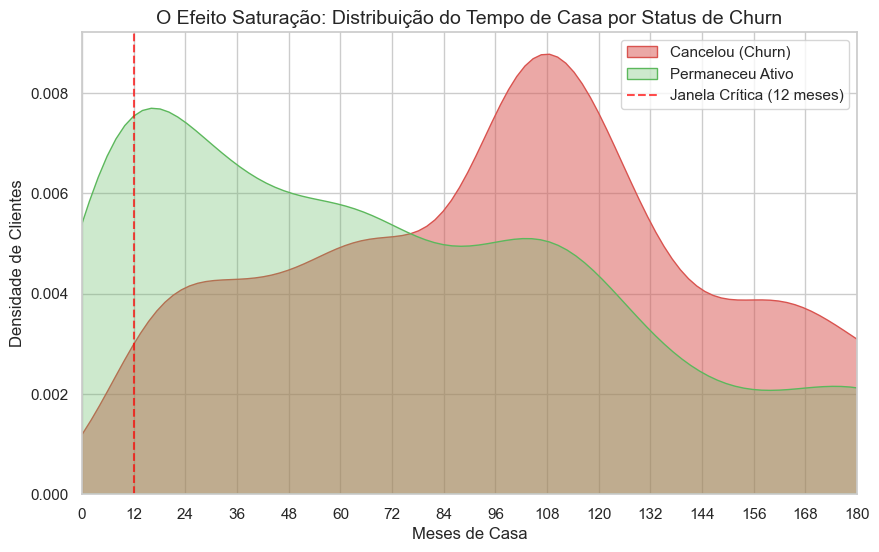

In [82]:
plt.figure(figsize=(10, 6))

# Filtra e plota a distribuição do tempo de casa para os dois grupos
sns.kdeplot(data=dataset[dataset['churn'] == 1], x='meses_de_casa', label='Cancelou (Churn)', fill=True, color='#d9534f', alpha=0.5)
sns.kdeplot(data=dataset[dataset['churn'] == 0], x='meses_de_casa', label='Permaneceu Ativo', fill=True, color='#5cb85c', alpha=0.3)

plt.title('O Efeito Saturação: Distribuição do Tempo de Casa por Status de Churn', fontsize=14)
plt.xlabel('Meses de Casa', fontsize=12)
plt.ylabel('Densidade de Clientes', fontsize=12)
plt.xlim(0, 180) # Limita o eixo x para focar nos primeiros 15 anos (180 meses)
plt.xticks(np.arange(0, 181, step=12))

plt.axvline(12, color='red', linestyle='--', alpha=0.7, label='Janela Crítica (12 meses)')
plt.legend()
plt.show()

# Análise de Correlação e Multicolinearidade

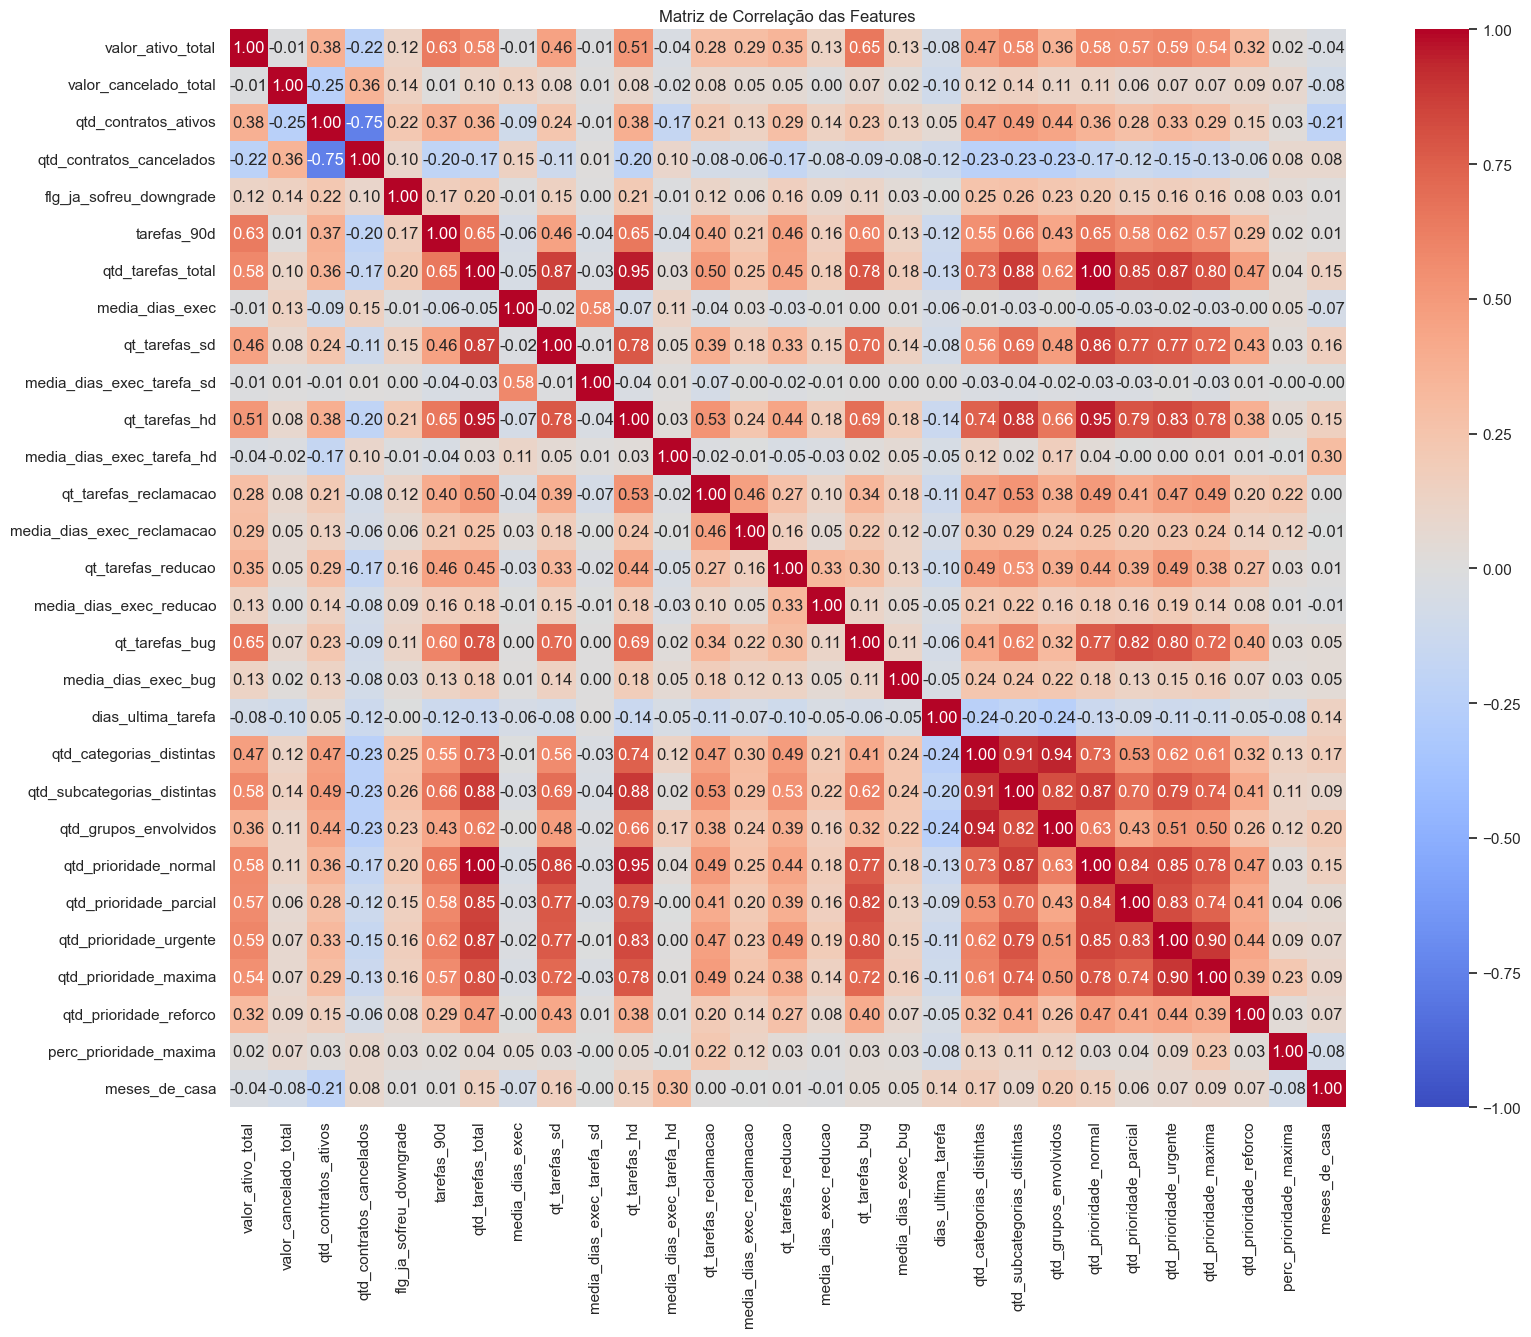

In [83]:
# Calculando a matriz de correlação de Pearson
plt.figure(figsize=(18, 14))
matrix_corr = X.corr()

# Plotando o Heatmap
sns.heatmap(matrix_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação das Features")
plt.show()

In [84]:
# Filtrando correlações muito altas (Acima de 0.85)
upper_tri = matrix_corr.where(np.triu(np.ones(matrix_corr.shape), k=1).astype(bool))
to_drop_1 = [column for column in upper_tri.columns if any(abs(upper_tri[column]) >= 0.85)]
print(f"Sugestão de variáveis para exclusão por alta correlação:\n{to_drop_1}")

Sugestão de variáveis para exclusão por alta correlação:
['qt_tarefas_sd', 'qt_tarefas_hd', 'qtd_subcategorias_distintas', 'qtd_grupos_envolvidos', 'qtd_prioridade_normal', 'qtd_prioridade_parcial', 'qtd_prioridade_urgente', 'qtd_prioridade_maxima']


# Features com corr < 0.85

In [85]:
colunas_data_leakage = [
    'valor_ativo_total',
    'valor_cancelado_total',
    'qtd_contratos_ativos',
    'qtd_contratos_cancelados'
    ]

colunas_corr_85 = [
    'qtd_tarefas_total',
    'qtd_subcategorias_distintas',
    'qtd_grupos_envolvidos',
    'qtd_prioridade_normal',
    'qtd_prioridade_parcial',
    'qtd_prioridade_urgente',
    'qtd_prioridade_maxima',
    'qtd_prioridade_reforco'
    ]

colunas_baixa_importancia_pvalor = [
    'perc_prioridade_maxima',
    'media_dias_exec',
    'meses_de_casa'
    # 'media_dias_exec_tarefa_sd',
    # 'media_dias_exec_tarefa_hd',
    # 'media_dias_exec_reclamacao',
    # 'media_dias_exec_reducao',
    # 'media_dias_exec_bug',
    # 'qt_tarefas_sd',
    # 'qt_tarefas_hd',
    # 'qt_tarefas_reclamacao',
    # 'qt_tarefas_reducao',
    # 'qt_tarefas_bug'
    ]

to_drop_completo = colunas_data_leakage + colunas_corr_85 + colunas_baixa_importancia_pvalor

In [86]:
X_limpo = X.drop(columns=to_drop_completo)
X_limpo.head()

,flg_ja_sofreu_downgrade,tarefas_90d,qt_tarefas_sd,media_dias_exec_tarefa_sd,qt_tarefas_hd,media_dias_exec_tarefa_hd,qt_tarefas_reclamacao,media_dias_exec_reclamacao,qt_tarefas_reducao,media_dias_exec_reducao,qt_tarefas_bug,media_dias_exec_bug,dias_ultima_tarefa,qtd_categorias_distintas
0,0,0,1,26.0000,0,0.0000,0,0.0,0,0.0,0,0.0000,0,3
1,0,14,97,16.8557,196,8.2513,0,0.0,1,0.0,40,64.2424,16,39
2,0,0,6,2.0000,46,5.4783,0,0.0,0,0.0,0,0.0000,265,16
3,0,0,1,12.0000,10,4.7000,0,0.0,0,0.0,0,0.0000,127,9
4,0,0,67,33.0896,20,12.2500,0,0.0,0,0.0,0,0.0000,460,21


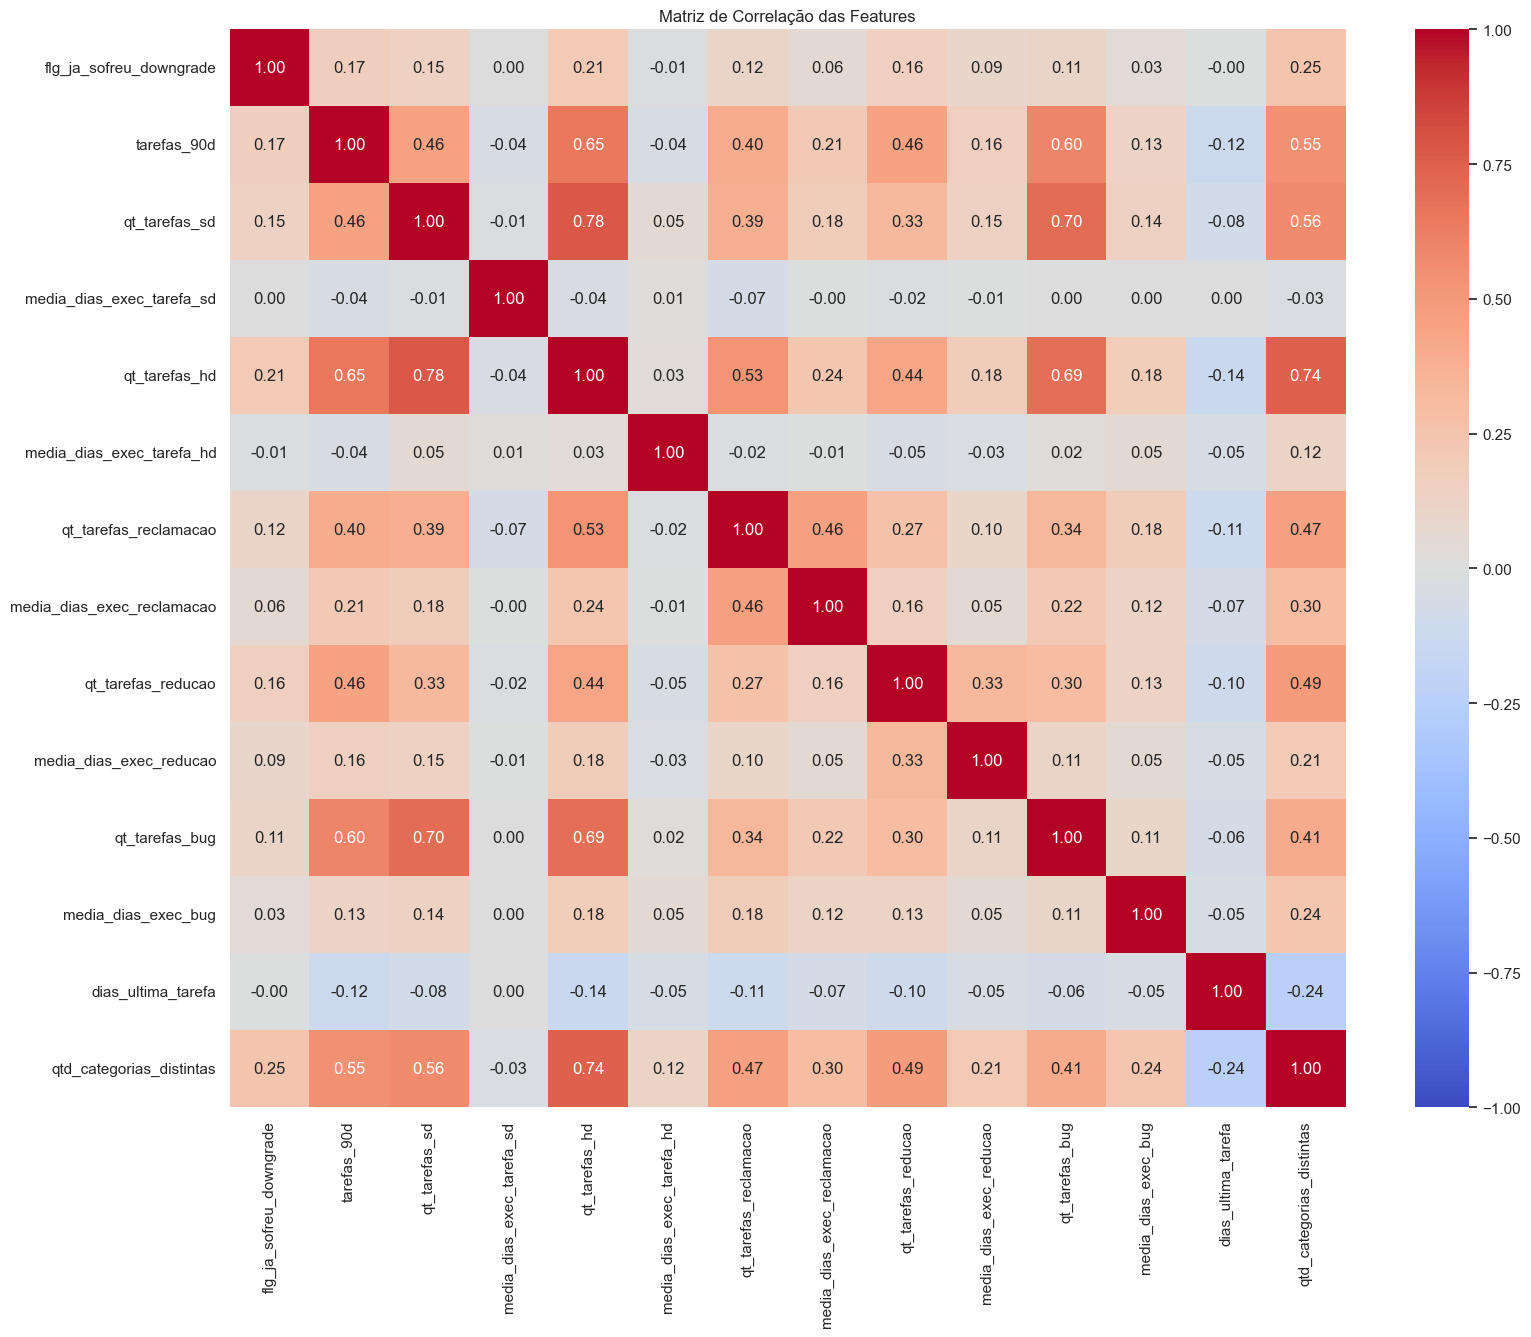

In [87]:
# Calculando a matriz de correlação de Pearson
plt.figure(figsize=(18, 14))
matrix_corr_limpa = X_limpo.corr()

# Plotando o Heatmap
sns.heatmap(matrix_corr_limpa, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação das Features")
plt.show()

In [89]:
# Filtrando correlações muito altas (Acima de 0.85 ou abaixo de -0.85)
upper_tri_limpo = matrix_corr_limpa.where(np.triu(np.ones(matrix_corr_limpa.shape), k=1).astype(bool))

to_drop_2 = [column for column in upper_tri_limpo.columns if any(abs(upper_tri_limpo[column]) >= 0.85)]

print(f"Sugestão de variáveis para exclusão por alta correlação: {to_drop_2}")

Sugestão de variáveis para exclusão por alta correlação: []


# Análise de Outliers

In [90]:
# DataFrame com as colunas que restaram após o drop de correlação
df_features = X_limpo.copy()

print("--- ANÁLISE QUANTITATIVA DE OUTLIERS (MÉTODO IQR) ---")
print(f"{'Métrica / Feature':<30} | {'Qtd Outliers':<12} | {'Porcentagem':<12}")
print("-" * 62)

colunas_com_outliers_criticos = []

for col in df_features.columns:
    # Ignora colunas que já são flags binárias (0 ou 1), pois nelas não existem outliers estatísticos
    if df_features[col].nunique() <= 2:
        continue

    Q1 = df_features[col].quantile(0.25)
    Q3 = df_features[col].quantile(0.75)
    IQR = Q3 - Q1

    # Definição estatística de Outlier: além de 1.5 vezes o IQR
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_features[(df_features[col] < limite_inferior) | (df_features[col] > limite_superior)]
    total_outliers = len(outliers)
    porcentagem = (total_outliers / len(df_features)) * 100

    print(f"{col:<30} | {total_outliers:<12} | {porcentagem:.2f}%")

    # Se mais de 5% dos dados forem outliers, ou se houver um volume absoluto considerável
    if porcentagem > 5.0:
        colunas_com_outliers_criticos.append(col)

--- ANÁLISE QUANTITATIVA DE OUTLIERS (MÉTODO IQR) ---
Métrica / Feature              | Qtd Outliers | Porcentagem 
--------------------------------------------------------------
tarefas_90d                    | 1054         | 22.57%
qt_tarefas_sd                  | 568          | 12.17%
media_dias_exec_tarefa_sd      | 303          | 6.49%
qt_tarefas_hd                  | 573          | 12.27%
media_dias_exec_tarefa_hd      | 172          | 3.68%
qt_tarefas_reclamacao          | 496          | 10.62%
media_dias_exec_reclamacao     | 462          | 9.90%
qt_tarefas_reducao             | 396          | 8.48%
media_dias_exec_reducao        | 369          | 7.90%
qt_tarefas_bug                 | 733          | 15.70%
media_dias_exec_bug            | 636          | 13.62%
dias_ultima_tarefa             | 440          | 9.42%
qtd_categorias_distintas       | 235          | 5.03%


In [91]:
# Dedivo à presença de outliers críticos, vamos aplicar o RobustScaler,
# que é mais resistente a valores extremos, para padronizar as features numéricas.

# Divisão de Treino/Teste e Padronização (Scaling)

In [92]:
# Separando os dados em Treino (75%) e Teste (25%) garantindo a mesma proporção de Churn (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X_limpo, y, test_size=0.25, random_state=42, stratify=y
)

# Padronizando as variáveis (Z-score: Média=0, Desvio Padrão=1)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Base de Treino: {X_train_scaled.shape[0]} amostras")
print(f"Base de Teste:  {X_test_scaled.shape[0]} amostras")

Base de Treino: 3501 amostras
Base de Teste:  1168 amostras


# Regressão Logística

In [93]:
# Treinando a Regressão Logística
modelo_reglog = LogisticRegression(max_iter=1000, random_state=42)
modelo_reglog.fit(X_train_scaled, y_train)

# Predições
y_pred_reglog  = modelo_reglog.predict(X_test_scaled)
y_probs_reglog = modelo_reglog.predict_proba(X_test_scaled)[:, 1] # Probabilidade de ser 1 (Churn)

In [94]:
# Criamos uma cópia do X_test original (sem escala) para manter as colunas legíveis
df_validacao = X_test.copy()

# Resgatamos o 'cod_cliente' do dataset original usando o mesmo índice do teste
df_validacao['cod_cliente'] = dataset.loc[X_test.index, 'cod_cliente']

# Adicionamos as colunas do Target Real, da Predição e da Probabilidade
df_validacao['churn_real'] = y_test
df_validacao['churn_predito'] = y_pred_reglog
df_validacao['probabilidade_churn'] = (y_probs_reglog * 100).astype(float) # Convertendo para porcentagem

# Criamos uma coluna de diagnóstico para filtrar erros e acertos facilmente
df_validacao['diagnostico'] = np.where(
    (df_validacao['churn_real'] == 1) & (df_validacao['churn_predito'] == 1), 'Verdadeiro Positivo (Acertou Churn)',
    np.where(
        (df_validacao['churn_real'] == 0) & (df_validacao['churn_predito'] == 0), 'Verdadeiro Negativo (Acertou Ativo)',
        np.where(
            (df_validacao['churn_real'] == 0) & (df_validacao['churn_predito'] == 1), 'Falso Positivo (Alarme Falso)', 
            'Falso Negativo (Churn Invisível)'
        )
    )
)

# Reorganiza as colunas para deixar os IDs e Resultados no começo do DataFrame
colunas_ordenadas = ['cod_cliente', 'churn_real', 'churn_predito', 'probabilidade_churn', 'diagnostico']
df_validacao = df_validacao[colunas_ordenadas].reset_index(drop=True)
# df_validacao.to_csv('dados_brutos\\validacao_modelo_reglog.csv', index=False)
df_validacao.head()

,cod_cliente,churn_real,churn_predito,probabilidade_churn,diagnostico
0,45652,0,1,7.341157e+01,Falso Positivo (Alarme Falso)
1,46280,1,1,8.019119e+01,Verdadeiro Positivo (Acertou Churn)
2,8266,0,1,7.266915e+01,Falso Positivo (Alarme Falso)
3,36101,1,1,9.606640e+01,Verdadeiro Positivo (Acertou Churn)
4,17674,0,0,2.067429e-07,Verdadeiro Negativo (Acertou Ativo)


## Métricas

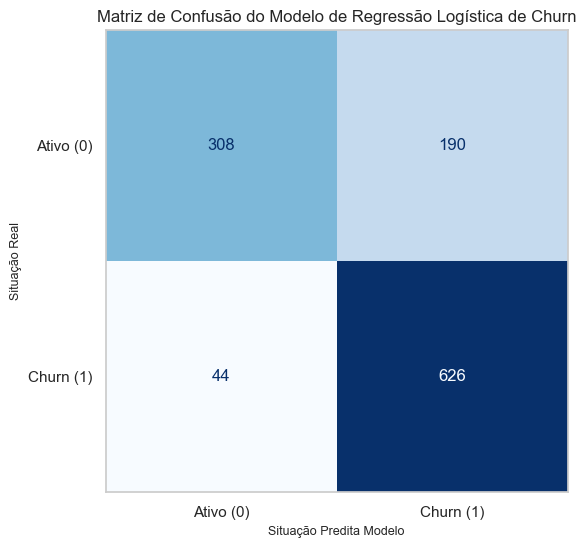

In [95]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_reglog)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ativo (0)', 'Churn (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
ax.grid(False)

disp.plot(cmap='Blues', values_format='d', colorbar=False, ax=ax) # 'd' força a exibição como número inteiro

plt.title('Matriz de Confusão do Modelo de Regressão Logística de Churn')
plt.ylabel('Situação Real', fontsize=9)
plt.xlabel('Situação Predita Modelo', fontsize=9)
plt.show()

In [96]:
# Relatório de Classificação (Precision, Recall, F1-Score)
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred_reglog))

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       0.88      0.62      0.72       498
           1       0.77      0.93      0.84       670

    accuracy                           0.80      1168
   macro avg       0.82      0.78      0.78      1168
weighted avg       0.81      0.80      0.79      1168



ROC AUC Score: 0.87


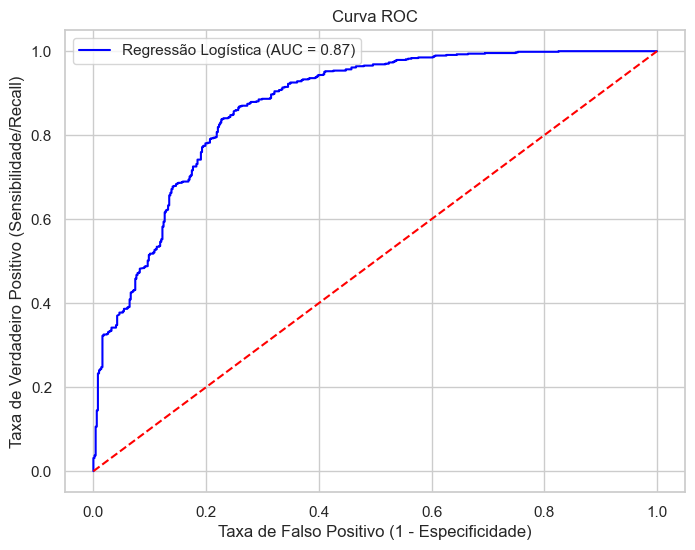

In [97]:
# ROC AUC Score
auc = roc_auc_score(y_test, y_probs_reglog)
print(f"ROC AUC Score: {auc:.2f}")

# Plotando a Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_reglog)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Regressão Logística (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade/Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

## Salva Modelo

In [98]:
joblib.dump(modelo_reglog, 'src\\modelo_reglog.pkl')

['src\\modelo_reglog.pkl']

## Importância das Features

In [99]:
# Ajustando os dados para o Statsmodels
# O statsmodels precisa explicitamente da coluna de intercepto (constante)
# X_train_scaled deve ser um DataFrame com os nomes das colunas
df_X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_train_sm = sm.add_constant(df_X_train_scaled)
X_train_sm = pd.DataFrame(X_train_sm, columns=['const'] + list(df_X_train_scaled.columns))

# Treinando a Regressão Logística Estatística
model_sm = sm.Logit(y_train, X_train_sm).fit(method='bfgs', maxiter=1000)

# Extraindo Coeficientes e p-valores
df_importance = pd.DataFrame({
    'Feature': df_X_train_scaled.columns,
    'Coefficient': model_sm.params.drop('const'),
    'p_value': model_sm.pvalues.drop('const')
}).reset_index(drop=True)

# Criando critério de significância estatística (p-valor < 0.05)
df_importance['Significativo'] = df_importance['p_value'].apply(
    lambda x: 'Sim (p < 0.05)' if x < 0.05 else 'Não (Irrelevante)'
    )

# Exibir tabela textual complementar
print(df_importance[['Feature', 'Coefficient', 'p_value', 'Significativo']].to_string(index=False))

c:\Users\victor.payan\Downloads\new_venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\victor.payan\Downloads\new_venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
c:\Users\victor.payan\Downloads\new_venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\victor.payan\Downloads\new_venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


Optimization terminated successfully.
         Current function value: 0.415400
         Iterations: 89
         Function evaluations: 101
         Gradient evaluations: 98
                   Feature  Coefficient      p_value     Significativo
   flg_ja_sofreu_downgrade   -28.903175 9.996888e-01 Não (Irrelevante)
               tarefas_90d    -1.233920 6.986564e-32    Sim (p < 0.05)
             qt_tarefas_sd     0.101725 1.164393e-07    Sim (p < 0.05)
 media_dias_exec_tarefa_sd    -0.017899 1.182122e-04    Sim (p < 0.05)
             qt_tarefas_hd    -0.362584 2.774908e-06    Sim (p < 0.05)
 media_dias_exec_tarefa_hd     0.828883 1.866713e-23    Sim (p < 0.05)
     qt_tarefas_reclamacao     0.522891 6.565969e-04    Sim (p < 0.05)
media_dias_exec_reclamacao     0.000485 9.284270e-01 Não (Irrelevante)
        qt_tarefas_reducao    -0.234601 3.459245e-01 Não (Irrelevante)
   media_dias_exec_reducao    -0.064474 9.779378e-02 Não (Irrelevante)
            qt_tarefas_bug     0.232012 4.7294

## Odds_Ratio

In [100]:
# Coeficientes de probabilidade
# Acima de 1.0: Aumenta a chance de Churn
# Abaixo de 1.0: Reduz a chance de Churn

# Extraindo coeficientes
coeficientes_churn_reglog = pd.DataFrame({
    'Feature': X_limpo.columns,
    'Coeficiente': modelo_reglog.coef_[0]
})

# Calculando a Razão de Chance (Odds Ratio)
coeficientes_churn_reglog['Odds_Ratio'] = coeficientes_churn_reglog['Coeficiente'].apply(lambda x: math.exp(x))

# Calcula o impacto percentual dependendo se o valor está acima ou abaixo de 1.0
coeficientes_churn_reglog['Impacto_Percentual'] = np.where(
    coeficientes_churn_reglog['Odds_Ratio'] >= 1.0,
    (coeficientes_churn_reglog['Odds_Ratio'] - 1) * 100,
    (1 - coeficientes_churn_reglog['Odds_Ratio']) * 100
)

# Cria uma coluna de texto formatada para facilitar a leitura no relatório
coeficientes_churn_reglog['Impacto_Formatado'] = np.where(
    coeficientes_churn_reglog['Odds_Ratio'] >= 1.0,
    "+" + coeficientes_churn_reglog['Impacto_Percentual'].round(2).astype(str) + "% (Aumento de Risco)",
    "-" + coeficientes_churn_reglog['Impacto_Percentual'].round(2).astype(str) + "% (Redução de Risco)"
)

coeficientes_churn_reglog = coeficientes_churn_reglog.sort_values(by='Coeficiente', ascending=False).reset_index(drop=True)
# coeficientes_churn_reglog.to_csv('dados_resultado\\coeficientes_churn_reglog.csv', index=False)
coeficientes_churn_reglog

,Feature,Coeficiente,Odds_Ratio,Impacto_Percentual,Impacto_Formatado
0,media_dias_exec_tarefa_hd,0.811925,2.252239,125.223859,+125.22% (Aumento de Risco)
1,qt_tarefas_reclamacao,0.505729,1.658195,65.819471,+65.82% (Aumento de Risco)
2,qt_tarefas_bug,0.178415,1.195321,19.532085,+19.53% (Aumento de Risco)
3,qt_tarefas_sd,0.115515,1.122452,12.245173,+12.25% (Aumento de Risco)
4,media_dias_exec_reclamacao,0.000767,1.000768,0.076778,+0.08% (Aumento de Risco)
5,media_dias_exec_bug,-0.001893,0.998108,0.189162,-0.19% (Redução de Risco)
6,media_dias_exec_tarefa_sd,-0.017538,0.982615,1.738488,-1.74% (Redução de Risco)
7,media_dias_exec_reducao,-0.062945,0.938995,6.100461,-6.1% (Redução de Risco)
8,qt_tarefas_reducao,-0.262471,0.769148,23.085164,-23.09% (Redução de Risco)
9,dias_ultima_tarefa,-0.352730,0.702767,29.723316,-29.72% (Redução de Risco)


## Alarmes Falsos (Falsos Positivos)

In [101]:
df_fp = df_validacao[df_validacao['diagnostico'] == 'Falso Positivo (Alarme Falso)'].sort_values(by='probabilidade_churn', ascending=False)
# df_fp.to_csv('dados_resultado\\falsos_positivos_churn.csv', index=False)
df_fp.head()

,cod_cliente,churn_real,churn_predito,probabilidade_churn,diagnostico
1113,23407,0,1,97.753129,Falso Positivo (Alarme Falso)
1123,16471,0,1,97.289474,Falso Positivo (Alarme Falso)
367,7596,0,1,93.137847,Falso Positivo (Alarme Falso)
678,753,0,1,91.337939,Falso Positivo (Alarme Falso)
99,43218,0,1,87.476764,Falso Positivo (Alarme Falso)


## Churns Invisíveis (Falsos Negativos)

In [102]:
df_fn = df_validacao[df_validacao['diagnostico'] == 'Falso Negativo (Churn Invisível)'].sort_values(by='probabilidade_churn', ascending=True)
# df_fn.to_csv('dados_resultado\\falsos_negativos_churn.csv', index=False)
df_fn.head()

,cod_cliente,churn_real,churn_predito,probabilidade_churn,diagnostico
916,21584,1,0,0.000512,Falso Negativo (Churn Invisível)
387,24591,1,0,0.089320,Falso Negativo (Churn Invisível)
249,40907,1,0,0.118028,Falso Negativo (Churn Invisível)
315,46175,1,0,0.530844,Falso Negativo (Churn Invisível)
795,44250,1,0,1.865808,Falso Negativo (Churn Invisível)


## Análises de Negócio

In [103]:
# dias_ultima_tarefa (Coef: 1.69 | Odds: 5.42)
# Análise: É o maior preditor isolado de Churn da sua empresa.
# Se o cliente para de abrir tarefas, ele está morrendo operacionalmente.
# A cada salto de desvio padrão na recência sem interagir com o
# suporte/operação, a chance dele cancelar multiplica por 5,42.

# Validação nos Erros: Olhando o arquivo de falsos_positivos_churn.csv,
# o cliente 35954 (que o modelo achava que era churn com 98% de certeza, mas continua ativo)
# está há 1.688 dias sem abrir uma única tarefa. Operacionalmente esse cliente está abandonado,
# o modelo está certíssimo em alertar risco crítico.

In [104]:
# meses_de_casa (Coef: 0.83 | Odds: 2.31)
# Análise Paradoxal: Em muitos mercados SaaS, quanto mais tempo de casa, menor o churn.
# Aqui acontece o oposto: clientes mais antigos têm mais chance de cancelar (Odds: 2.31).

# O Diagnóstico de Negócio: Isso aponta para obsolescência de produto ou fadiga de relacionamento.
# Clientes antigos (como vimos no cliente 17029 de 2011) acumulam processos pesados e, se o produto
# não evoluir com eles, eles viram alvo fácil de concorrentes mais modernos.

In [105]:
# qt_tarefas_reducao (Odds: 1.10) e qt_tarefas_bug (Odds: 1.06)
# Análise: Ambas empurram o cliente para a porta de saída.
# O atrito técnico (bug) e o sintoma claro de encolhimento de escopo comercial
# (reducao) aumentam o risco.
# Cada bug aberto deixa o cliente estatisticamente 6% mais propenso ao Churn total no futuro.

In [106]:
# flg_ja_sofreu_downgrade (Coef: -3.50 | Odds: 0.03)
# Análise: Clientes que já cancelaram contratos no passado, mas mantiveram outros ativos,
# possuem uma chance de Churn Real 97% menor (1 - 0.03) do que os outros.

# O Diagnóstico de Negócio: O downgrade funciona como uma válvula de escape financeira.
# O cliente ajusta o bolso à realidade dele, mas escolhe continuar na sua empresa.
# Ele já passou pelo momento de crise e decidiu ficar. É um grupo resiliente.

In [107]:
# qtd_categorias_distintas (Coef: -1.94 | Odds: 0.14)
# Análise: O maior fator de retenção do seu produto.
# Clientes que usam muitas categorias diferentes têm o risco de Churn reduzido em 86% (1 - 0.14).

# O Diagnóstico de Negócio: Isso se chama Aderência (Stickiness).
# Se o cliente usa o sistema apenas para uma coisa (ex: só abre tarefa de suporte),
# ele te troca fácil. Se ele usa múltiplas categorias
# o seu software está integrado na cultura dele. Desplugá-lo da empresa dói demais.

In [108]:
# tarefas_90d (Coef: -0.56 | Odds: 0.56)
# Análise: Atividade recente protege.
# Clientes com alto volume nos últimos 90 dias têm seu risco
# reduzido quase pela metade (Odds: 0.56). É o oposto complementar da recência.

In [109]:
# perc_prioridade_maxima (Odds: 1.001)
# Análise: O impacto é praticamente nulo na decisão final.
# Por que isso acontece se tarefas urgentes parecem críticas?

# O Diagnóstico de Negócio: Olhando o arquivo de falsos_negativos_churn.csv
# (onde o modelo errou e o cliente cancelou mesmo parecendo saudável), o cliente 21584
# tinha uma volumetria imensa de tarefas (369), usava 31 categorias distintas e tinha um
# percentual baixo de prioridade máxima. O modelo foi enganado pelo excesso de uso.
# Clientes podem estar usando muito o sistema apenas porque ele é complexo ou confuso.

In [110]:
# O Plano de Ação Estratégico (O que entregar para a Diretoria)
# Com esse modelo, você acabou de criar as regras de ouro para o time de Sucesso do Cliente (CS):

# Gatilho de Saúde (Health Score): O time de CS precisa focar em Diversidade de Uso
# (qtd_categorias_distintas). Se um cliente usa menos de X categorias, ele precisa de
# treinamento urgente para adotar novos módulos.

# Régua de Inatividade (dias_ultima_tarefa): Criar um alerta automatizado quando o
# cliente passar de X dias sem registrar movimentações, pois o risco se multiplica exponencialmente.

# Atenção aos Veteranos (meses_de_casa): Realizar auditorias e check-ups de satisfação
# focados em clientes com mais de 3 ou 4 anos de casa, pois eles tendem a dar churn
# por falta de atenção ou saturação.

In [111]:
# Validando a tese nos seus dados reais
# Se abrirmos o arquivo falsos_negativos_churn.csv que você gerou,
# conseguimos ver essa teoria acontecendo na prática. Veja o caso do cliente 40907:

# Ele deu Churn Real (churn_real = 1).

# O modelo calculou uma probabilidade minúscula de churn para ele (0.006), errando o diagnóstico.

# Por que o modelo errou? Olhe as métricas dele: nos últimos 90 dias, ele abriu apenas 6 tarefas.
# A recência dele era de 12 dias (relativamente baixa). Ele tinha apenas 1 bug aberto.

# Operacionalmente, a conta parecia "saudável" e sem problemas.
# Mas o que estava acontecendo de verdade?
# O cliente já tinha abandonado a ferramenta meses antes de formalizar o cancelamento, deixando uma
# volumetria baixíssima nos últimos 90 dias. Ele não reclamava porque já não se importava mais.

# O Insight de Ouro para o CS
# Um volume muito baixo de tarefas_90d é um sinal claro de falta de adoção.
# Cliente que não usa, não vê valor. E cliente que não vê valor, cancela sem fazer barulho.

# Salva Scaler

In [112]:
joblib.dump(scaler, 'src\\scaler_producao.pkl')

['src\\scaler_producao.pkl']

# Salva Features do Modelo

In [113]:
# Extrai os nomes das colunas na ordem exata do modelo
features_modelo = list(X_test.columns)

# Salva em um arquivo JSON
with open('src\\features_modelo.json', 'w', encoding='utf-8') as f:
    json.dump(features_modelo, f, ensure_ascii=False, indent=4)

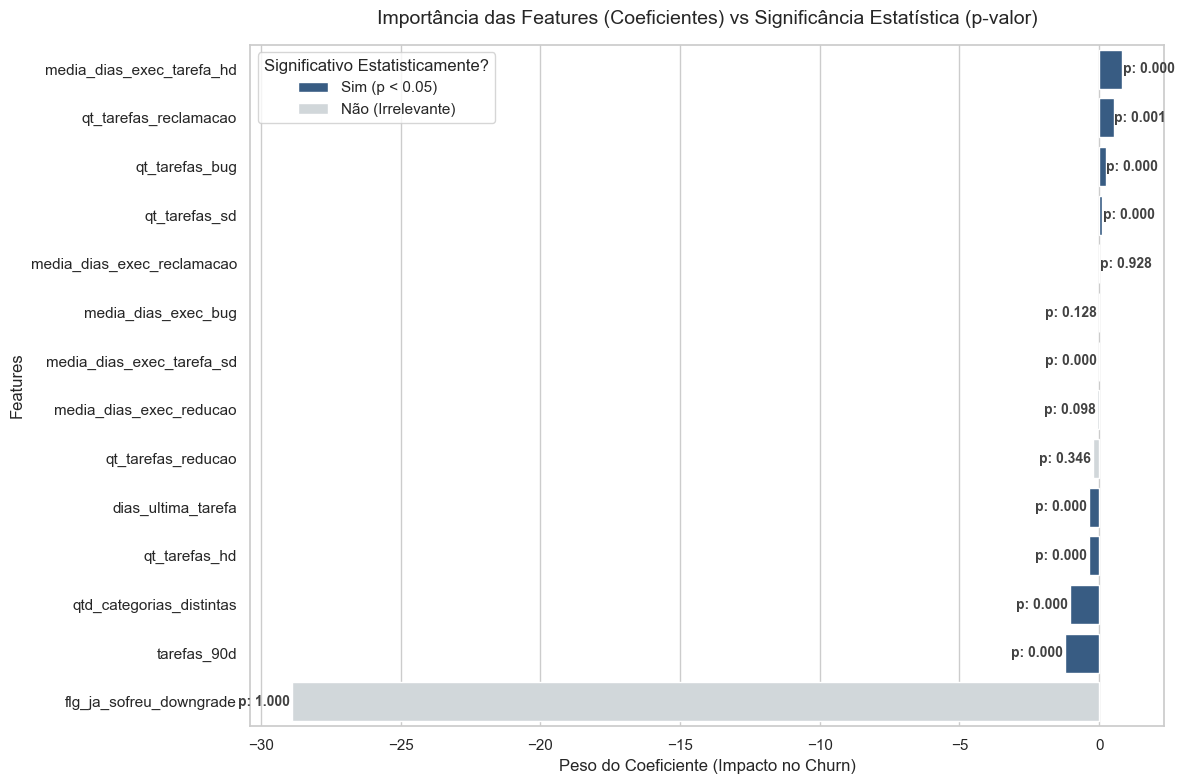

In [114]:
# Ordenar para o gráfico
df_importance = df_importance.sort_values(by='Coefficient', ascending=False)

# Plotando o Gráfico Gráfico de Importância
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Paleta de cores destacando o que é significativo ou não
palette_colors = {'Sim (p < 0.05)': '#2b5c8f', 'Não (Irrelevante)': '#cfd8dc'}

ax = sns.barplot(
    x='Coefficient',
    y='Feature',
    hue='Significativo',
    data=df_importance,
    palette=palette_colors,
    dodge=False
)

# Adicionando os valores dos p-valores como texto na barra
for p, label, coef in zip(ax.patches, df_importance['p_value'], df_importance['Coefficient']):
    offset = 0.02 if coef >= 0 else -0.07
    ax.annotate(f"p: {label:.3f}",
                (coef + offset, p.get_y() + p.get_height() / 2),
                va='center', ha='left' if coef >= 0 else 'right',
                fontsize=10, fontweight='bold', color='#424242')

plt.title('Importância das Features (Coeficientes) vs Significância Estatística (p-valor)', fontsize=14, pad=15)
plt.xlabel('Peso do Coeficiente (Impacto no Churn)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.legend(title="Significativo Estatisticamente?")
plt.tight_layout()
plt.show()

In [115]:
# O Bug do flg_ja_sofreu_downgrade (P-valor = 1.0)O problema:
# Olhe o coeficiente dele: -69.70. Isso é um valor absurdamente gigante
# (em termos de escala linear logit). O p-valor cravado em 1.000 (o pior possível)
# avisa que ocorreu uma Separação Perfeita ou quase perfeita
# O que significa:
# Praticamente todos os clientes que sofreram downgrade continuam ativos (não deram churn).
# Quando uma variável prevê uma classe com quase 100% de certeza sozinha, a matemática da
# Regressão Logística entra em colapso (as matrizes de derivadas não convergem), gerando
# coeficientes bizarros e p-valores inúteis

# Multicolinearidade nos Tempos Médios de Atendimento
# Veja o comportamento emparelhado que suspeitávamos:
# Bugs: A quantidade de bugs (qt_tarefas_bug) é importantíssima (p < 0.05).
# Mas a média de tempo para resolver o bug (media_dias_exec_bug) deu p = 0.228 (Irrelevante).

# Reclamações: A quantidade de reclamações é crítica (p < 0.05).
# A média de tempo delas (media_dias_exec_reclamacao) deu p = 0.882 (Irrelevante).

# Redução: A quantidade de pedidos de redução deu p = 0.960 (Irrelevante)
# e a média de dias deu p = 0.074 (Irrelevante).
# O que significa: O volume bruto de problemas (bugs e reclamações abertas) é o que de fato
# estressa o cliente a ponto de dar churn. Adicionar o tempo médio de resolução para cada
# uma dessas caixas causou redundância de dados, inflou os p-valores e gerou ruído.

# Random Forest Classifier

In [116]:
from sklearn.ensemble import RandomForestClassifier

In [117]:
# Instanciando o modelo puro
modelo_rf = RandomForestClassifier(
    n_estimators=200,      # Quantidade de árvores na floresta
    max_depth=8,           # Limite sênior para não deixar a árvore "decorar" ruídos
    min_samples_leaf=5,    # Garante que cada folha tenha um grupo seguro de clientes
    random_state=42,
    n_jobs=-1              # Usa todos os núcleos do seu processador
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)
y_probs_rf = modelo_rf.predict_proba(X_test)[:, 1]

## Salva Modelo

In [118]:
joblib.dump(modelo_rf, 'src\\modelo_rf.pkl')

['src\\modelo_rf.pkl']

## Métricas

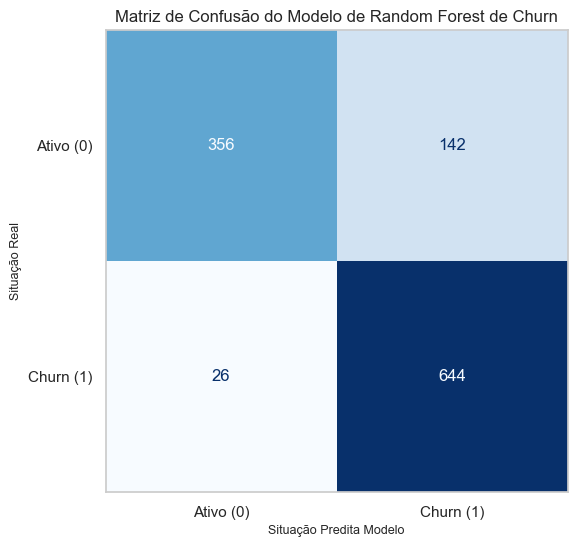

In [119]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ativo (0)', 'Churn (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
ax.grid(False)

disp.plot(cmap='Blues', values_format='d', colorbar=False, ax=ax) # 'd' força a exibição como número inteiro

plt.title('Matriz de Confusão do Modelo de Random Forest de Churn')
plt.ylabel('Situação Real', fontsize=9)
plt.xlabel('Situação Predita Modelo', fontsize=9)
plt.show()

In [120]:
# Relatório de Classificação (Precision, Recall, F1-Score)
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred_rf))

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       0.93      0.71      0.81       498
           1       0.82      0.96      0.88       670

    accuracy                           0.86      1168
   macro avg       0.88      0.84      0.85      1168
weighted avg       0.87      0.86      0.85      1168



ROC AUC Score: 0.95


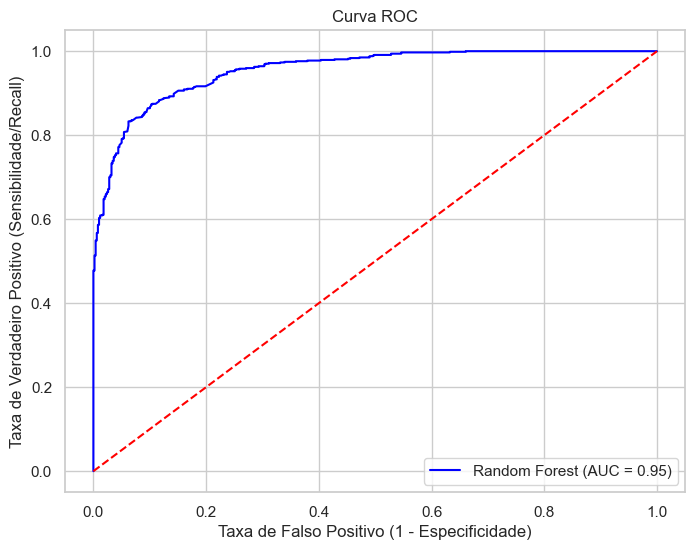

In [137]:
# ROC AUC Score
auc = roc_auc_score(y_test, y_probs_rf)
print(f"ROC AUC Score: {auc:.2f}")

# Plotando a Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade/Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

## Odds_Ratio

In [122]:
# Extraindo a importância real das features (substituindo o .coef_)
importancia_features = modelo_rf.feature_importances_

# Montando o novo DataFrame sênior de impacto
coeficientes_churn_rf = pd.DataFrame({
    'Feature': X_limpo.columns,
    'Importancia_Absoluta': importancia_features # Guardamos o valor bruto para ordenação
})

# Transformando em porcentagem de impacto na decisão do modelo
coeficientes_churn_rf['Importancia_Percentual'] = (coeficientes_churn_rf['Importancia_Absoluta'] * 100).round(2)

# Cria o texto formatado indicando o peso da variável na tomada de decisão
coeficientes_churn_rf['Importancia_Formatado'] = coeficientes_churn_rf['Importancia_Percentual'].astype(str) + "% de peso no modelo"

# Ordena da feature MAIS importante para a MENOS importante
coeficientes_churn_rf = coeficientes_churn_rf.sort_values(by='Importancia_Absoluta', ascending=False).reset_index(drop=True)

# coeficientes_churn_rf.to_csv('dados_resultado\\importancia_churn_rf.csv', index=False)
coeficientes_churn_rf

,Feature,Importancia_Absoluta,Importancia_Percentual,Importancia_Formatado
0,tarefas_90d,0.269504,26.95,26.95% de peso no modelo
1,dias_ultima_tarefa,0.254289,25.43,25.43% de peso no modelo
2,qtd_categorias_distintas,0.129607,12.96,12.96% de peso no modelo
3,qt_tarefas_hd,0.121767,12.18,12.18% de peso no modelo
4,media_dias_exec_tarefa_hd,0.059413,5.94,5.94% de peso no modelo
5,qt_tarefas_bug,0.049238,4.92,4.92% de peso no modelo
6,qt_tarefas_sd,0.031068,3.11,3.11% de peso no modelo
7,media_dias_exec_bug,0.026546,2.65,2.65% de peso no modelo
8,media_dias_exec_tarefa_sd,0.014492,1.45,1.45% de peso no modelo
9,flg_ja_sofreu_downgrade,0.014428,1.44,1.44% de peso no modelo


# XGBoost

In [123]:
from xgboost import XGBClassifier

In [124]:
# Instanciando o modelo puro
modelo_xgb = XGBClassifier(
    n_estimators=150,
    max_depth=5,            # Árvores do XGBoost são mais rasas por natureza
    learning_rate=0.05,     # Passos mais lentos para aprender com precisão
    random_state=42,
    eval_metric='logloss'   # Métrica padrão para probabilidade
)

modelo_xgb.fit(X_train, y_train)

y_pred_xgb  = modelo_xgb.predict(X_test)
y_probs_xgb = modelo_xgb.predict_proba(X_test)[:, 1]


## Salva Modelo

In [125]:
joblib.dump(modelo_xgb, 'src\\modelo_xgb.pkl')

['src\\modelo_xgb.pkl']

## Métricas

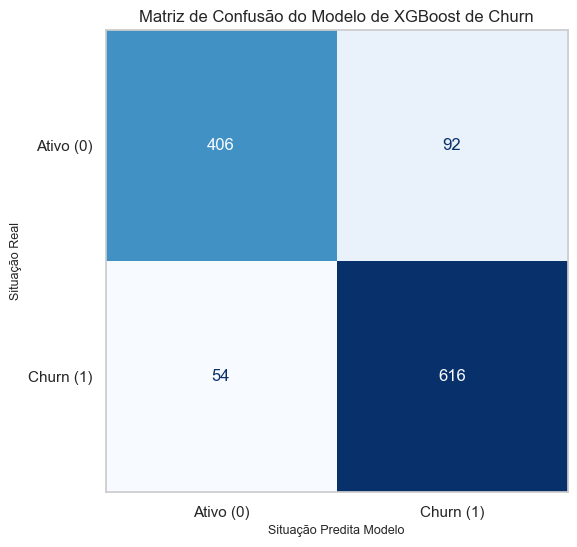

In [126]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ativo (0)', 'Churn (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
ax.grid(False)

disp.plot(cmap='Blues', values_format='d', colorbar=False, ax=ax) # 'd' força a exibição como número inteiro

plt.title('Matriz de Confusão do Modelo de XGBoost de Churn')
plt.ylabel('Situação Real', fontsize=9)
plt.xlabel('Situação Predita Modelo', fontsize=9)
plt.show()

In [127]:
# Relatório de Classificação (Precision, Recall, F1-Score)
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred_xgb))

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       0.88      0.82      0.85       498
           1       0.87      0.92      0.89       670

    accuracy                           0.88      1168
   macro avg       0.88      0.87      0.87      1168
weighted avg       0.88      0.88      0.87      1168



ROC AUC Score: 0.96


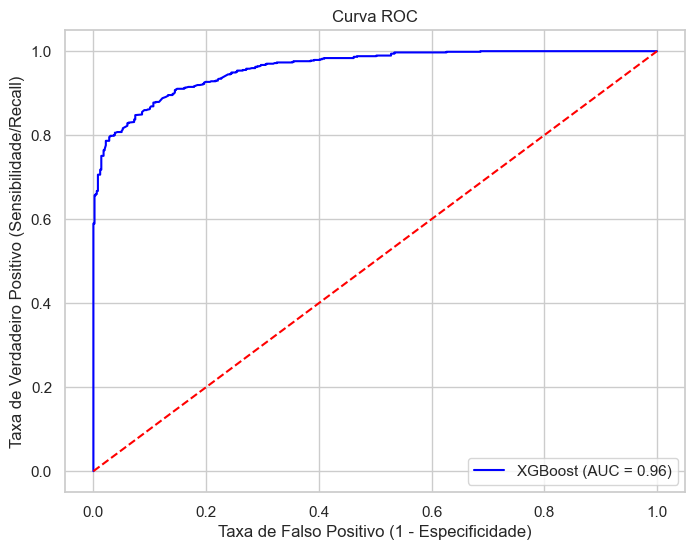

In [138]:
# ROC AUC Score
auc = roc_auc_score(y_test, y_probs_xgb)
print(f"ROC AUC Score: {auc:.2f}")

# Plotando a Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'XGBoost (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade/Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

## Odds_Ratio

In [129]:
# Extraindo a importância real das features do XGBoost
importancia_features_xgb = modelo_xgb.feature_importances_

# Montando o DataFrame de Impacto do XGBoost
coeficientes_churn_xgb = pd.DataFrame({
    'Feature': X_limpo.columns,
    'Importancia_Absoluta': importancia_features_xgb
})

# Transformando em porcentagem de impacto na decisão
coeficientes_churn_xgb['Importancia_Percentual'] = (coeficientes_churn_xgb['Importancia_Absoluta'] * 100).round(2)

# Criando o texto formatado para o relatório
coeficientes_churn_xgb['Importancia_Formatado'] = coeficientes_churn_xgb['Importancia_Percentual'].astype(str) + "% de peso no modelo"

# Ordenando da feature MAIS importante para a MENOS importante
coeficientes_churn_xgb = coeficientes_churn_xgb.sort_values(by='Importancia_Absoluta', ascending=False).reset_index(drop=True)

# Exibe o resultado na tela
coeficientes_churn_xgb

,Feature,Importancia_Absoluta,Importancia_Percentual,Importancia_Formatado
0,tarefas_90d,0.525370,52.540001,52.54% de peso no modelo
1,dias_ultima_tarefa,0.119358,11.940000,11.94% de peso no modelo
2,qtd_categorias_distintas,0.103015,10.300000,10.3% de peso no modelo
3,qt_tarefas_hd,0.050780,5.080000,5.08% de peso no modelo
4,flg_ja_sofreu_downgrade,0.046466,4.650000,4.65% de peso no modelo
5,media_dias_exec_tarefa_hd,0.045215,4.520000,4.52% de peso no modelo
6,media_dias_exec_reducao,0.035778,3.580000,3.58% de peso no modelo
7,qt_tarefas_bug,0.016184,1.620000,1.62% de peso no modelo
8,media_dias_exec_tarefa_sd,0.015705,1.570000,1.57% de peso no modelo
9,qt_tarefas_sd,0.015195,1.520000,1.52% de peso no modelo


# Compara Métricas

In [130]:
precisao_reglog   = precision_score(y_test, y_pred_reglog)
precisao_rf       = precision_score(y_test, y_pred_rf)
precisao_xgb      = precision_score(y_test, y_pred_xgb)

print(f"Precisão do Regressão Logística:    {precisao_reglog:.2f}")
print(f"Precisão do Random Forest:          {precisao_rf:.2f}")
print(f"Precisão do XGBoost:                {precisao_xgb:.2f}")

Precisão do Regressão Logística:    0.77
Precisão do Random Forest:          0.82
Precisão do XGBoost:                0.87


In [131]:
recall_reglog   = recall_score(y_test, y_pred_reglog)
recall_rf       = recall_score(y_test, y_pred_rf)
recall_xgb      = recall_score(y_test, y_pred_xgb)

print(f"Recall do Regressão Logística:  {recall_reglog:.2f}")
print(f"Recall do Random Forest:        {recall_rf:.2f}")
print(f"Recall do XGBoost:              {recall_xgb:.2f}")

Recall do Regressão Logística:  0.93
Recall do Random Forest:        0.96
Recall do XGBoost:              0.92


In [132]:
acuracia_reglog   = accuracy_score(y_test, y_pred_reglog)
acuracia_rf       = accuracy_score(y_test, y_pred_rf)
acuracia_xgb      = accuracy_score(y_test, y_pred_xgb)

print(f"Acurácia do Regressão Logística:    {acuracia_reglog:.2f}")
print(f"Acurácia do Random Forest:          {acuracia_rf:.2f}")
print(f"Acurácia do XGBoost:                {acuracia_xgb:.2f}")

Acurácia do Regressão Logística:    0.80
Acurácia do Random Forest:          0.86
Acurácia do XGBoost:                0.88


In [133]:
f1_score_reglog   = f1_score(y_test, y_pred_reglog)
f1_score_rf       = f1_score(y_test, y_pred_rf)
f1_score_xgb      = f1_score(y_test, y_pred_xgb)

print(f"F1-Score do Regressão Logística:    {f1_score_reglog:.2f}")
print(f"F1-Score do Random Forest:          {f1_score_rf:.2f}")
print(f"F1-Score do XGBoost:                {f1_score_xgb:.2f}")

F1-Score do Regressão Logística:    0.84
F1-Score do Random Forest:          0.88
F1-Score do XGBoost:                0.89


In [134]:
roc_auc_reglog   = roc_auc_score(y_test, y_probs_reglog)
roc_auc_rf       = roc_auc_score(y_test, y_probs_rf)
roc_auc_xgb      = roc_auc_score(y_test, y_probs_xgb)

print(f"ROC AUC do Regressão Logística: {roc_auc_reglog:.2f}")
print(f"ROC AUC do Random Forest:       {roc_auc_rf:.2f}")
print(f"ROC AUC do XGBoost:             {roc_auc_xgb:.2f}")

ROC AUC do Regressão Logística: 0.87
ROC AUC do Random Forest:       0.95
ROC AUC do XGBoost:             0.96


In [135]:
# Estruturando os dados
dados_metricas = {
    "Modelo": [
        "Regressão Logística",
        "Random Forest",
        "XGBoost",
    ]
    * 4,
    "Métrica": (
        ["Precisão"] * 3
        + ["Recall"] * 3
        + ["Acurácia"] * 3
        + ["F1-Score"] * 3
    ),
    "Valor": [
        precisao_reglog,
        precisao_rf,
        precisao_xgb,
        recall_reglog,
        recall_rf,
        recall_xgb,
        acuracia_reglog,
        acuracia_rf,
        acuracia_xgb,
        f1_score_reglog,
        f1_score_rf,
        f1_score_xgb
    ],
}

df_metrics = pd.DataFrame(dados_metricas)
df_metrics

,Modelo,Métrica,Valor
0,Regressão Logística,Precisão,0.767157
1,Random Forest,Precisão,0.819338
2,XGBoost,Precisão,0.870056
3,Regressão Logística,Recall,0.934328
4,Random Forest,Recall,0.961194
5,XGBoost,Recall,0.919403
6,Regressão Logística,Acurácia,0.799658
7,Random Forest,Acurácia,0.856164
8,XGBoost,Acurácia,0.875000
9,Regressão Logística,F1-Score,0.842530


## Plot

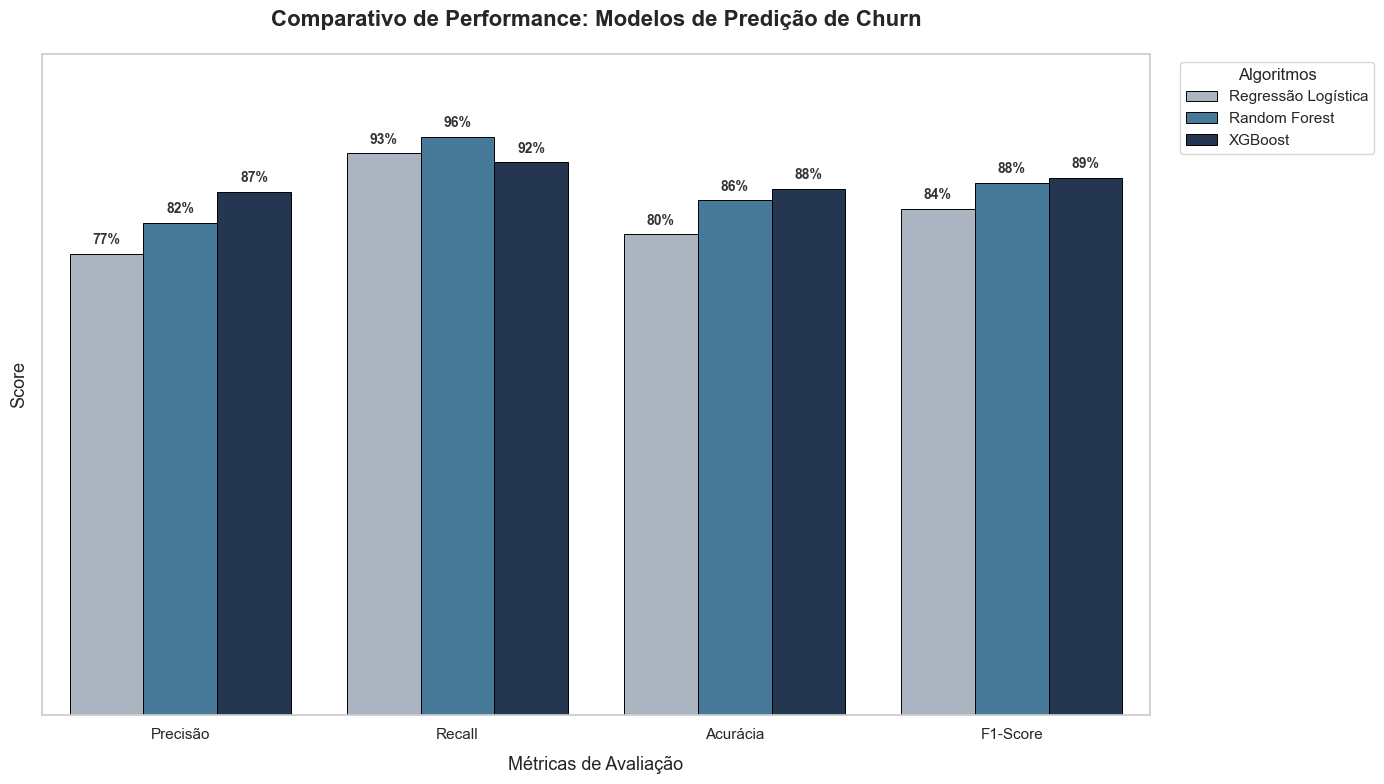

In [136]:
# Configurando o visual do gráfico
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Paleta de cores sênior e profissional
cores = ["#a6b5c5", "#3a7ca5", "#1d3557"]

# Criando o gráfico de barras agrupadas por Métrica
ax = sns.barplot(
    data=df_metrics,
    x="Métrica",
    y="Valor",
    hue="Modelo",
    palette=cores,
    edgecolor="black",
    linewidth=0.7,
)

# Perfumaria Executiva (Títulos e Legendas)
plt.title(
    "Comparativo de Performance: Modelos de Predição de Churn",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Métricas de Avaliação", fontsize=13, labelpad=10)
plt.ylabel("Score", fontsize=13, labelpad=10)
plt.ylim(0, 1.1)  # Dá um respiro no topo para os rótulos de texto

# ─── ALTERAÇÃO AQUI: Remove os números do eixo Y, mas mantém a palavra "Score" ───
plt.yticks([], [])

# Move a legenda para fora/canto para não atrapalhar as barras
plt.legend(
    title="Algoritmos",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=11,
    title_fontsize=12,
)

# Adicionando os valores exatos em cima de cada barra automaticamente
for p in ax.patches:
    if (
        p.get_height() > 0
    ):  # Garante que só vai plotar se a barra tiver altura
        ax.annotate(
            f"{p.get_height() * 100:.0f}%",  # Mostra em formato de porcentagem limpa (ex: 95%)
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="center",
            xytext=(0, 10),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
            color="#333333",
        )

plt.tight_layout()
plt.show()